# Iris Dataset Analysis
The Iris dataset is a well-known dataset used in data analysis and machine learning. It contains measurements of 150 iris flowers from three species: setosa, versicolor, and virginica.

Each flower is described using four features:
  - Sepal length
  - Sepal width
  - Petal length
  - Petal width

The aim of this notebook is to explore the dataset, understand how the values are distributed, and identify patterns that can help distinguish between the species.

## Importing Libraries
The following libraries are used for data analysis and visualisation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import os

# Create output folder
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

## Loading the Dataset
The dataset is loaded from a CSV file into a pandas DataFrame.

The dataset did not contain column names, so they are added manually when loading the data.

In [2]:
# Create columnn names
column_names = ["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]

df = pd.read_csv("data/iris.csv", names=column_names)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Dataset Overview
This section shows the structure of the dataset.

The Iris dataset is known to contain no missing values, but a check was done to confirm this.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

The dataset contains 150 rows and 5 columns. Four columns are numerical values and one represents the species.

There are no missing values, so the dataset is complete and ready for analysis.

## Summary Statistics
Summary statistics provide an overview of each variable, including the average, minimum, maximum and spread of the data.

In [5]:
summary = df.describe()

summary_file = os.path.join(OUTPUT_DIR, "summary.txt")

with open(summary_file, "w") as f:
    f.write(summary.to_string())

summary

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


The summary statistic show that sepal length has an average value of approximately 5.84 cm. Petal length and petal width show a wider range of values compared to sepal measurements.

The greater variation in petal measurements suggest that these features may be more useful for distinguishing between species.

## Histograms
Histograms are used to show how values of each variable are distributed.

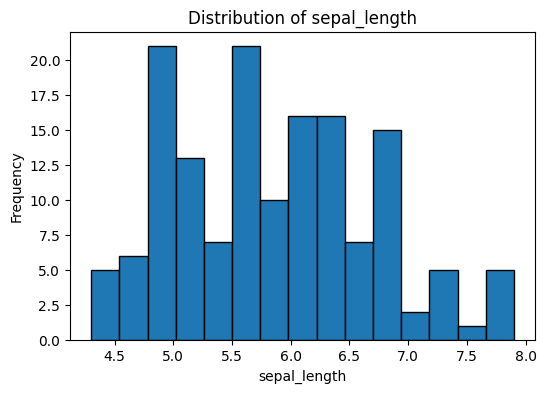

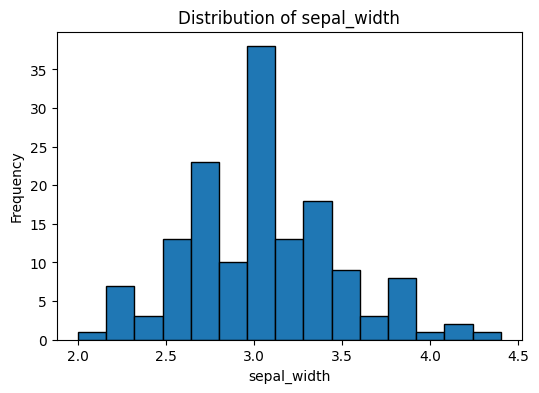

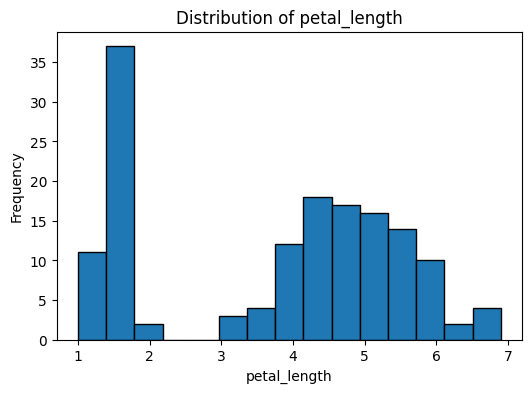

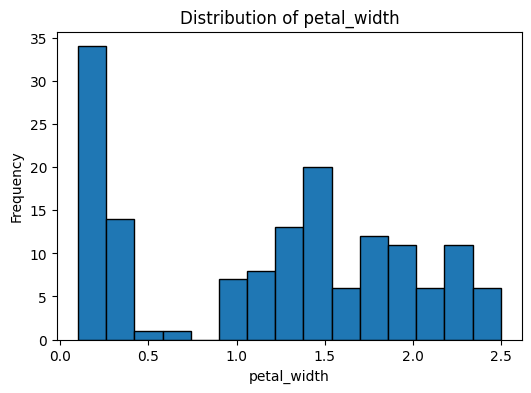

In [6]:
NUM_BINS = 15

for column in df.select_dtypes(include="number").columns:
    plt.figure(figsize=(6, 4))

    plt.hist(df[column], bins=NUM_BINS, edgecolor="black")

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    filename = os.path.join(OUTPUT_DIR, f"{column}_hist.png")
    plt.savefig(filename)

    plt.close

The histograms show that most variables follow a roughly normal distribution.

Sepal width appears more spread out, while petal length and petal width show clearer groupings. This suggests that petal measurements may be more useful for distinguishing between species.

## Scatter plot
Scatter plot are used to examine relationships between variables and identify patterns between species.

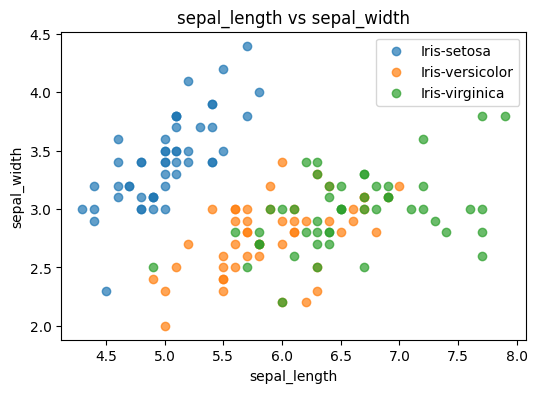

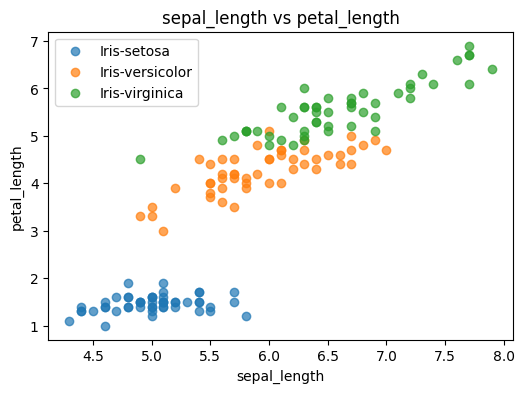

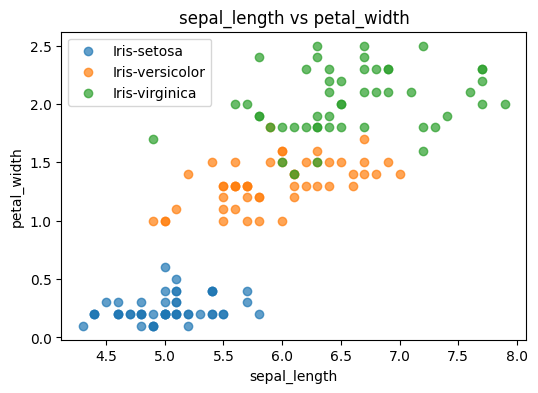

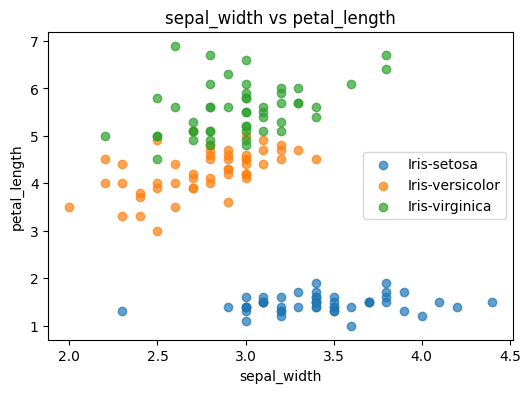

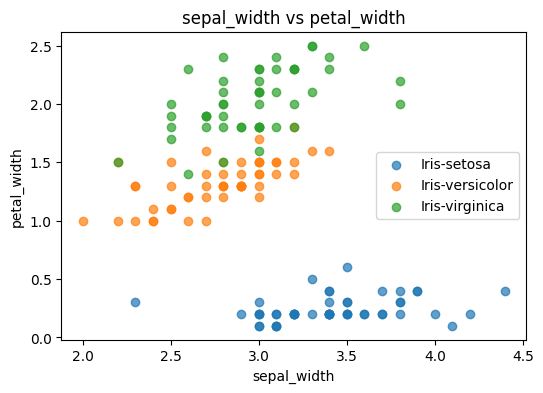

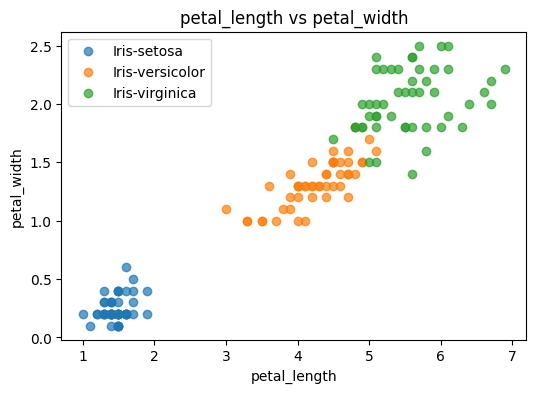

In [7]:
numeric_columns = df.select_dtypes(include="number").columns

for x, y in itertools.combinations(numeric_columns, 2):
    plt.figure(figsize=(6, 4))

    for species in df["species"].unique():
        subset = df[df["species"] == species]

        plt.scatter(
            subset[x],
            subset[y],
            label=species,
            alpha=0.7
        )
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f"{x} vs {y}")
        plt.legend()

        filename = os.path.join(OUTPUT_DIR, f"{x}_vs_{y}.png")
        plt.savefig(filename)

        plt.close

The scatter plot shows the relationship between variables.

Petal length and petal width form distict clusters, with setosa clearly seperated from the other species. Veriscolor and virginica overlap slightly but can still be distinguished.

Sepal measurements show more overlap, making them less useful for classification.

## Additional Analysis
The dataset is grouped by species to compare average values.

In [8]:
species_means = df.groupby("species").mean()
species_means

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


The grouped results show clear differences between species.

Setosa has the smallest petal measurements, while virginica has the largest. Veriscolor lies between the two.

This confirms that the petal measurements are the most useful for distinguishing between species.

## Pairplot
A pairplot shows all relationships between variables in a single visualisation.

<function matplotlib.pyplot.close(fig: "None | int | str | Figure | Literal['all']" = None) -> 'None'>

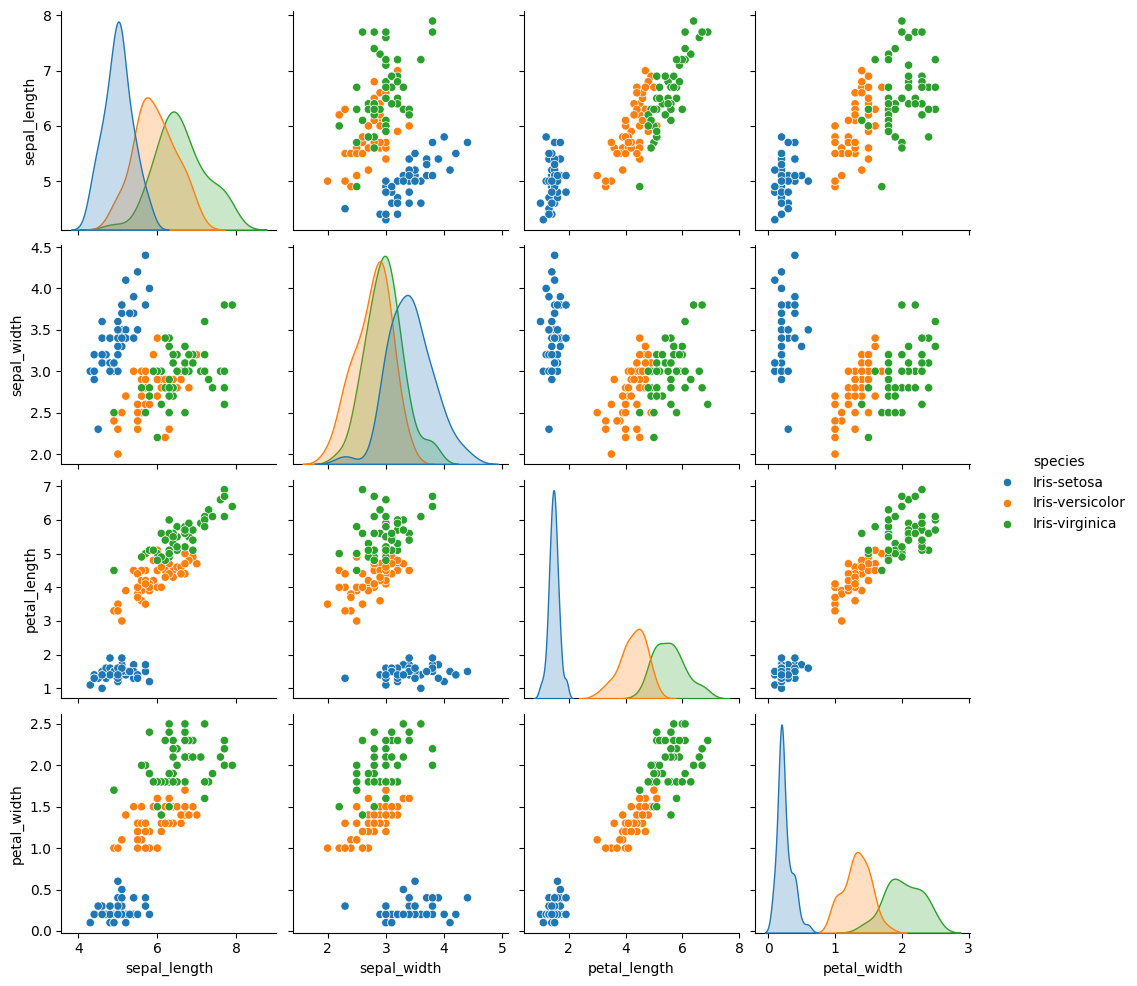

In [9]:
pairplot = sns.pairplot(df, hue="species")

pairplot.savefig(os.path.join(OUTPUT_DIR, "pairplot.png"))
plt.close

The pairplot clearly shows how species are seperated, particularly when using petal measurments. Setosa is completely distinct, while the other two species show some overlap.

## Conclusion
This analysis explored the Iris dataset using summary statistics and visualisation techniques.

The results show that petal length and petal width are the most useful features for distinguishing between species. These features showed clear seperation  in scatterplots and distinct groupings in histograms.

Sepal measurements showed more overlap and are less effective for classification.

Overall, the dataset demonstrates how simple analysis techiques can reveal meaningful patterns in data.